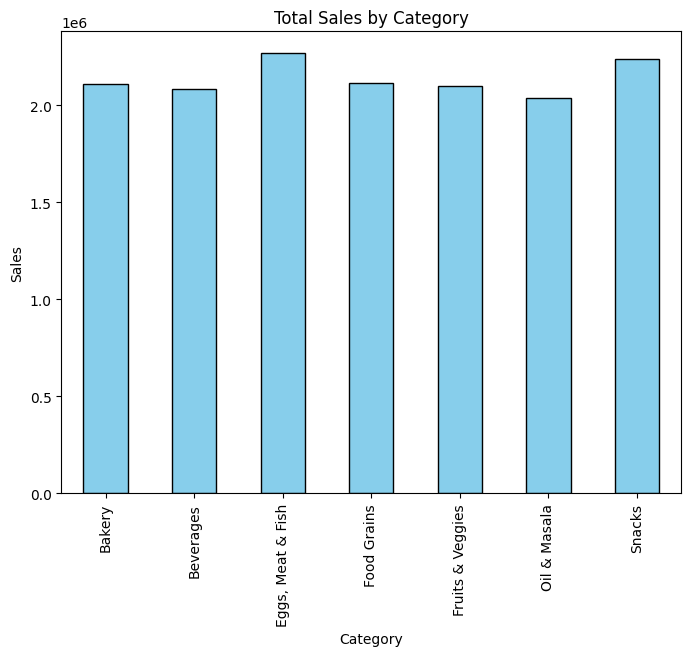

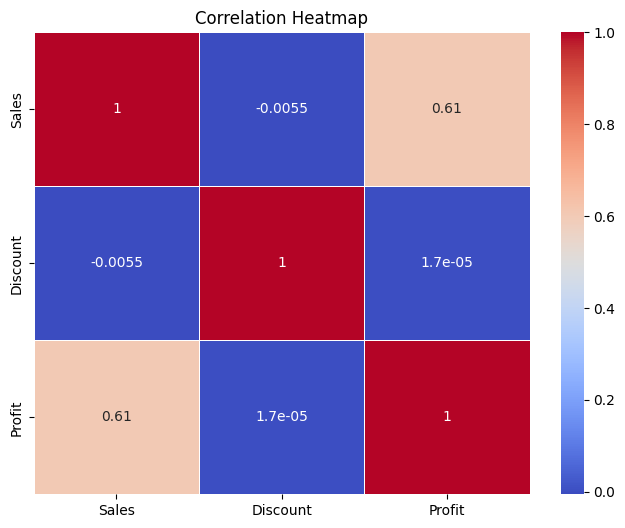

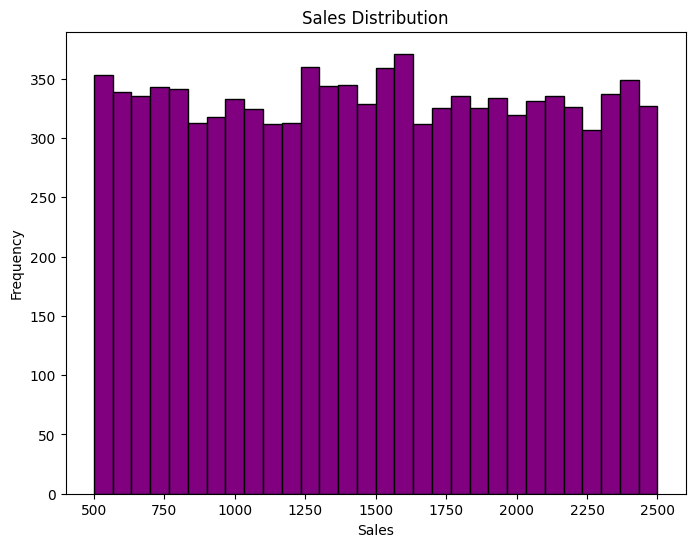

/tmp/ipython-input-2979605883.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Region", y="Sales", data=data, palette="Set2")


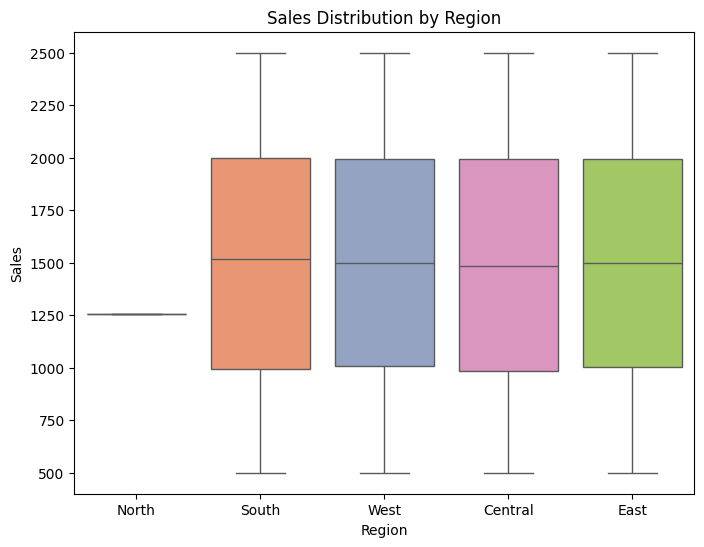

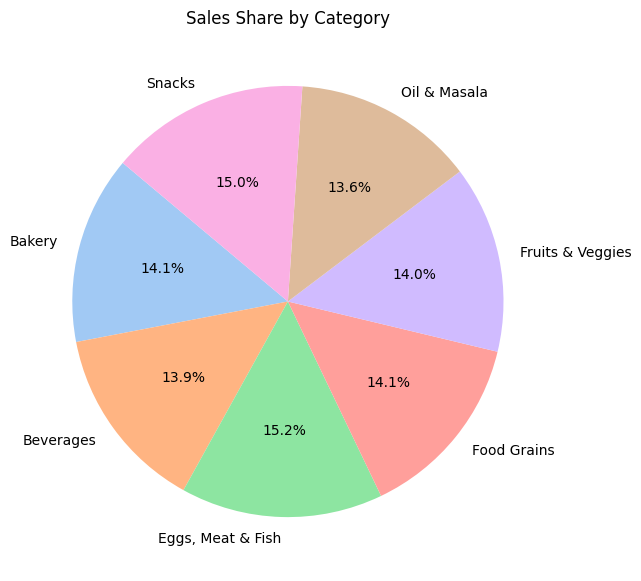

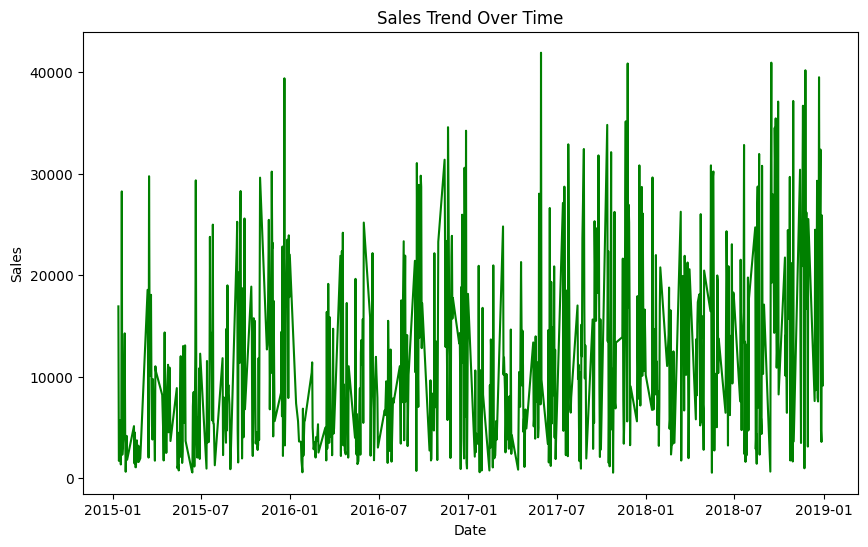

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (UPDATE THE PATH TO YOUR LOCAL FILE LOCATION)
data = pd.read_csv("/content/Supermart Grocery Sales - Retail Analytics Dataset.csv")

# -----------------------------
# 1. Bar Graph: Sales by Category
# -----------------------------
plt.figure(figsize=(8,6))
data.groupby("Category")["Sales"].sum().plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Total Sales by Category")
plt.ylabel("Sales")
plt.xlabel("Category")
plt.show()

# -----------------------------
# 2. Heatmap: Correlation between numeric features
# -----------------------------
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# -----------------------------
# 3. Histogram: Distribution of Sales
# -----------------------------
plt.figure(figsize=(8,6))
plt.hist(data["Sales"], bins=30, color="purple", edgecolor="black")
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

# -----------------------------
# 4. Box Plot: Sales by Region
# -----------------------------
plt.figure(figsize=(8,6))
sns.boxplot(x="Region", y="Sales", data=data, palette="Set2")
plt.title("Sales Distribution by Region")
plt.show()

# -----------------------------
# 5. Pie Chart: Sales Share by Category
# -----------------------------
plt.figure(figsize=(7,7))
category_sales = data.groupby("Category")["Sales"].sum()
plt.pie(category_sales, labels=category_sales.index, autopct="%1.1f%%", startangle=140, colors=sns.color_palette("pastel"))
plt.title("Sales Share by Category")
plt.show()

# -----------------------------
# 6. Line Chart: Sales Trend Over Time
# -----------------------------
if "Order Date" in data.columns:
    # Convert 'Order Date' to datetime, assuming MM/DD/YYYY format based on common CSV formats
    # Use errors='coerce' to turn unparseable dates into NaT (Not a Time)
    data["Order Date"] = pd.to_datetime(data["Order Date"], format="%m/%d/%Y", errors="coerce")

    # Drop rows where date conversion failed (if any) and group
    sales_trend = data.dropna(subset=["Order Date"]).groupby("Order Date")["Sales"].sum().reset_index()

    plt.figure(figsize=(10,6))
    plt.plot(sales_trend["Order Date"], sales_trend["Sales"], color="green")
    plt.title("Sales Trend Over Time")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.show()